In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

In [2]:
df = pd.read_csv("jp_morgan.csv")
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,3,CUST2412,ACC80131,Loan,Withdrawal,Personal Loan,Firm C,West,Manager 3,06-08-2023,33759.69057,126486.40830,0.225824,611,89
1,32,CUST1467,ACC74631,Current,Withdrawal,Home Loan,Firm D,North,Manager 2,08-11-2023,69319.19933,24834.76291,0.335717,817,174
2,9,CUST2699,ACC39482,Loan,Withdrawal,Credit Card,Firm D,West,Manager 4,15-05-2024,42831.48483,123007.43530,0.572453,332,31
3,42,CUST9535,ACC82947,Current,Withdrawal,Home Loan,Firm A,South,Manager 4,30-04-2023,70903.79697,73073.64225,0.571993,626,92
4,166,CUST7459,ACC39500,Credit,Payment,Home Loan,Firm D,South,Manager 4,16-02-2023,21948.97355,113405.32820,0.380675,411,13


In [3]:
df.dtypes

TransactionID          int64
CustomerID            object
AccountID             object
AccountType           object
TransactionType       object
Product               object
Firm                  object
Region                object
Manager               object
TransactionDate       object
TransactionAmount    float64
AccountBalance       float64
RiskScore            float64
CreditRating           int64
TenureMonths           int64
dtype: object

## Task 1 Data Cleaning

In [4]:
# Task 1.1 Remove/treat any special characters or non-numeric entries from financial fields.
df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

In [5]:
# Task 1.2 Convert currency amounts into numerical format.
df["TransactionAmount"] = pd.to_numeric(df["TransactionAmount"])
df["AccountBalance"] = pd.to_numeric(df["AccountBalance"])
df.dtypes

TransactionID          int64
CustomerID            object
AccountID             object
AccountType           object
TransactionType       object
Product               object
Firm                  object
Region                object
Manager               object
TransactionDate       object
TransactionAmount    float64
AccountBalance       float64
RiskScore            float64
CreditRating           int64
TenureMonths           int64
dtype: object

In [6]:
# Task 1.3 Validate and format date columns.
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"],format="%d-%m-%Y")
df.dtypes

TransactionID                 int64
CustomerID                   object
AccountID                    object
AccountType                  object
TransactionType              object
Product                      object
Firm                         object
Region                       object
Manager                      object
TransactionDate      datetime64[ns]
TransactionAmount           float64
AccountBalance              float64
RiskScore                   float64
CreditRating                  int64
TenureMonths                  int64
dtype: object

In [7]:
# Task 1.4 Ensure account types and transaction categories are standardized
df["TransactionType"] = df["TransactionType"].str.lower().str.strip()
df["AccountType"] = df["AccountType"].str.lower().str.strip()
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,3,CUST2412,ACC80131,loan,withdrawal,Personal Loan,Firm C,West,Manager 3,2023-08-06,33759.69057,126486.40830,0.225824,611,89
1,32,CUST1467,ACC74631,current,withdrawal,Home Loan,Firm D,North,Manager 2,2023-11-08,69319.19933,24834.76291,0.335717,817,174
2,9,CUST2699,ACC39482,loan,withdrawal,Credit Card,Firm D,West,Manager 4,2024-05-15,42831.48483,123007.43530,0.572453,332,31
3,42,CUST9535,ACC82947,current,withdrawal,Home Loan,Firm A,South,Manager 4,2023-04-30,70903.79697,73073.64225,0.571993,626,92
4,166,CUST7459,ACC39500,credit,payment,Home Loan,Firm D,South,Manager 4,2023-02-16,21948.97355,113405.32820,0.380675,411,13


## TASK 2: TRANSACTION ANALYSIS

### Task 2.1 Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.

In [8]:
#Creating Credit Column
df["Credit"] = df["TransactionAmount"].where( df["TransactionType"] == "deposit", 0)

In [9]:
#Creating Debit Column
df["Debit"] = df["TransactionAmount"].where(
    df["TransactionType"].isin(["withdrawal", "transfer", "payment"]), 0)

In [10]:
# Net Transaction
df["Net_Transaction"] = df["Credit"] - df["Debit"]

In [11]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Credit,Debit,Net_Transaction
0,3,CUST2412,ACC80131,loan,withdrawal,Personal Loan,Firm C,West,Manager 3,2023-08-06,33759.69057,126486.40830,0.225824,611,89,0.0,33759.69057,-33759.69057
1,32,CUST1467,ACC74631,current,withdrawal,Home Loan,Firm D,North,Manager 2,2023-11-08,69319.19933,24834.76291,0.335717,817,174,0.0,69319.19933,-69319.19933
2,9,CUST2699,ACC39482,loan,withdrawal,Credit Card,Firm D,West,Manager 4,2024-05-15,42831.48483,123007.43530,0.572453,332,31,0.0,42831.48483,-42831.48483
3,42,CUST9535,ACC82947,current,withdrawal,Home Loan,Firm A,South,Manager 4,2023-04-30,70903.79697,73073.64225,0.571993,626,92,0.0,70903.79697,-70903.79697
4,166,CUST7459,ACC39500,credit,payment,Home Loan,Firm D,South,Manager 4,2023-02-16,21948.97355,113405.32820,0.380675,411,13,0.0,21948.97355,-21948.97355


### Insight:
- Deposit transactions are recorded as credits.
- Withdrawal, transfer, and payment are recorded as debits.
- Net transaction shows whether the account is gaining or losing money.

#### Task 2.2 Plot trends in total credits vs. debits over time.

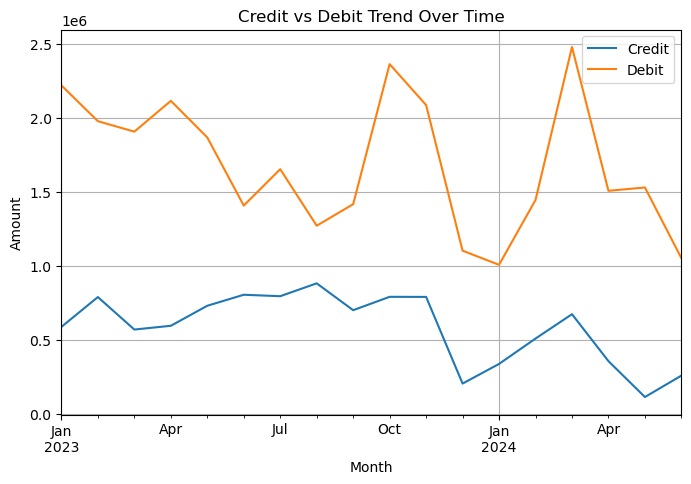

In [12]:
# Monthly Trend Graph
df["Month"] = df["TransactionDate"].dt.to_period("M")

monthly = df.groupby("Month")[["Credit", "Debit"]].sum()
monthly.plot(figsize=(8,5))
plt.title("Credit vs Debit Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid(True)
plt.show()

### Insight:
- Debit values are higher than credit in most months.
- This indicates customers are spending more than saving.
- Some months show spikes in debit, indicating high transaction activity.

#### Task 2.3 Identify top and bottom performing accounts based on net inflow.

In [13]:
#Top 5 Accounts
account_flow = df.groupby("AccountID")["Net_Transaction"].sum()
top5 = account_flow.nlargest(5)
top5_df = top5.reset_index()
top5_df

,AccountID,Net_Transaction
0,ACC54589,225122.495180
1,ACC67713,189071.785288
2,ACC74631,150954.104630
3,ACC87602,150860.567520
4,ACC22036,145164.795582


In [14]:
# Bottom 5 accounts
bottom5 = account_flow.nsmallest(5)
bottom5_df = bottom5.reset_index()
bottom5_df

,AccountID,Net_Transaction
0,ACC18140,-458219.210460
1,ACC55331,-448188.410346
2,ACC51593,-414370.119240
3,ACC11285,-373189.528410
4,ACC81631,-342531.377190


### Insight:
- Top accounts have strong positive net inflow, indicating financial stability.
- Bottom accounts show negative net inflow, indicating excessive withdrawals or risk behavior.

#### Task 2.4 Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions

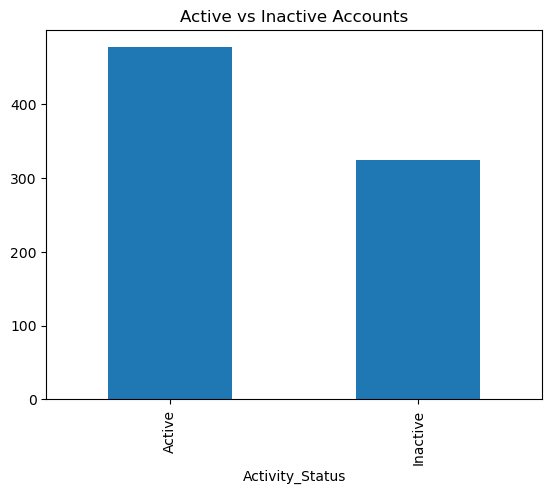

In [15]:
df = df.sort_values(by=["AccountID", "TransactionDate"])
df["Days_Gap"] = df.groupby("AccountID")["TransactionDate"].diff().dt.days
df["Activity_Status"] = df["Days_Gap"].apply(lambda x: "Inactive" if x >= 60 else "Active")
df["Activity_Status"].value_counts().plot(kind="bar")
plt.title("Active vs Inactive Accounts")
plt.show()

### Insight:
- Accounts with gaps greater than 60 days are inactive.
- Active accounts show frequent transaction behavior.

## Task 3: Customer Profile Building
#### Task 3.1 Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings.

In [57]:
# Count transactions per account
txn_count = df.groupby("AccountID")["TransactionID"].count().reset_index()

# Rename column for clarity
txn_count.rename(columns={"TransactionID": "Transaction_Count"}, inplace=True)

# Define activity level function
def activity_level(x):
    if x > 50:
        return "High"
    elif x >= 20:
        return "Medium"
    else:
        return "Low"

# Apply function
txn_count["Activity_Level"] = txn_count["Transaction_Count"].apply(activity_level)
txn_count.head(10)

,AccountID,Transaction_Count,Activity_Level
0,ACC10117,1,Low
1,ACC10996,4,Low
2,ACC11062,4,Low
3,ACC11188,3,Low
4,ACC11285,6,Low
5,ACC11837,1,Low
6,ACC12182,4,Low
7,ACC12334,2,Low
8,ACC13357,6,Low
9,ACC15228,5,Low


#### Rubric:
- High Activity: > 50 transactions
- Medium Activity: 20–50 transactions
- Low Activity: < 20 transactions

Insight:
High activity users frequently interact with their accounts, while low activity users may be inactive or less engaged.

### Task 3.2 Segment customers by average balance and transaction volume.

In [18]:
# Calculate average balance and total transaction volume
customer_summary = df.groupby("AccountID").agg({"AccountBalance": "mean","TransactionAmount": "sum"}).reset_index()

customer_summary.rename(columns={
    "AccountBalance": "Avg_Balance","TransactionAmount": "Transaction_Volume"}, inplace=True)

customer_summary.head()

,AccountID,Avg_Balance,Transaction_Volume
0,ACC10117,90780.256640,56317.920060
1,ACC10996,64046.568590,223757.534516
2,ACC11062,62784.100737,265928.583340
3,ACC11188,80558.926400,116557.954500
4,ACC11285,95745.546255,373189.528410


#### Insight- Customers with high balance and high volume are financially strong, while low balance customers may indicate financial risk.

### Task 3.3: Create Customer Profiles
#### Task 3.3.1: High-net inflow accounts

In [19]:
# Calculate net inflow per account
account_flow = df.groupby("AccountID")["Net_Transaction"].sum().reset_index()

# Define threshold (top 25%)
threshold = account_flow["Net_Transaction"].quantile(0.75)

# Create profile
account_flow["High_Inflow_Flag"] = account_flow["Net_Transaction"].apply(lambda x: "High Net Inflow" if x > threshold else "Normal")

account_flow.head()

,AccountID,Net_Transaction,High_Inflow_Flag
0,ACC10117,-56317.920060,Normal
1,ACC10996,124107.378684,High Net Inflow
2,ACC11062,-142721.038720,Normal
3,ACC11188,-116557.954500,Normal
4,ACC11285,-373189.528410,Normal


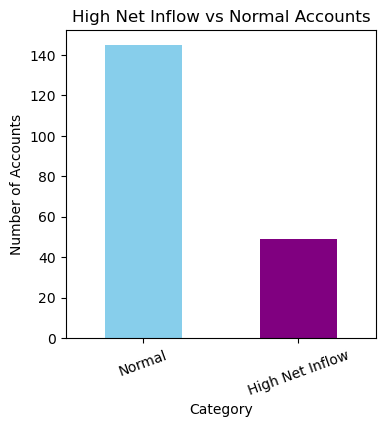

In [20]:
inflow_counts = account_flow["High_Inflow_Flag"].value_counts()
plt.figure(figsize=(4,4))
inflow_counts.plot(kind='bar',color=["skyblue","purple"])
plt.title("High Net Inflow vs Normal Accounts")
plt.xlabel("Category")
plt.ylabel("Number of Accounts")
plt.xticks(rotation=20)
plt.show()

#### Accounts with net transaction above the 75th percentile are classified as high inflow accounts.
#### Insight: These customers maintain strong financial inflow and are valuable for the bank.

### Task 3.3.2: High-frequency low-balance accounts

In [28]:
# Ensure Activity_Level already exists
df = pd.merge(df, txn_count[["AccountID", "Activity_Level"]], on="AccountID", how="left")
df["HighFreq_LowBal"] = df.apply(lambda row: "Yes"
    if (row["Activity_Level"] == "High" and row["AccountBalance"] < 2000)
    else "No", axis=1)

### Insight:No customers were identified under the high-frequency low-balance category based on the defined thresholds.
#### This indicates that:
#### - Customers maintain sufficient account balances, or
#### - The defined thresholds are strict.

### Task 3.3.3: Accounts with negative or near-zero balances

In [ ]:
df["Balance_Flag"] = df["AccountBalance"].apply(lambda x: "Negative/Near Zero" if x <= 1000 else "Normal")
df[["AccountID", "Activity_Level","AccountBalance", "Balance_Flag"]].head(10)

#### Accounts with balance less than or equal to 1000 are classified as negative or near-zero.
#### Insight:These customers have very low financial reserves and may be at financial risk.

## TASK 4: FINANCIAL RISK IDENTIFICATION
#### Task 4.1- Identify Overdraft & Large Withdrawal Accounts

In [ ]:
# Overdraft Accounts
df["Overdraft_Flag"] = df.apply(
    lambda row: "Yes"
    if (row["AccountBalance"] < 0 or row["Debit"] > row["AccountBalance"])
    else "No",
    axis=1)
# df[df["Overdraft_Flag"] == "Yes"][["AccountID", "AccountBalance", "Debit"]]
plt.figure(figsize=(4,4))
df["Overdraft_Flag"].value_counts().plot(kind="bar",color=["skyblue","red"])
plt.title("Overdraft Accounts Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

### Visualization: This chart shows how many accounts fall into overdraft.
#### Insight:Overdraft accounts indicate financial instability.

In [ ]:
# Large_Withdrawal Accounts
df["Large_Withdrawal"] = df["Debit"].apply(
    lambda x: "Yes" if x > 10000 else "No")
# df[df["Large_Withdrawal"] == "Yes"][["AccountID", "Debit"]]
df["Large_Withdrawal"].value_counts().plot(kind="bar",color=["skyblue","lightgreen"])
plt.title("Large Withdrawal Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

#### This bar chart shows the distribution of large withdrawals.
#### Insight:A higher number of large withdrawals may indicate risky financial behavior.

### Task 4.2: Calculate balance volatility (Std & CV)

In [ ]:
import numpy as np

std_balance = df["AccountBalance"].std()
mean_balance = df["AccountBalance"].mean()
cv = std_balance / mean_balance

print("Standard Deviation:", std_balance)
print("Coefficient of Variation:", cv)

#### Balance volatility was measured using standard deviation and coefficient of variation.
#### Insight: Higher variation indicates unstable financial behavior.

### Task 4.3: Detect anomalies using Z-score

In [ ]:
from scipy.stats import zscore

df["z_score"] = zscore(df["TransactionAmount"])
df["Anomaly"] = df["z_score"].apply(lambda x: "Yes" if abs(x) > 3 else "No")

# Show anomalies
df[df["Anomaly"] == "Yes"][["TransactionAmount", "z_score", "Anomaly"]]

### Z-score method was used to detect outliers in transaction amounts.
### Insight:Outliers indicate unusual or suspicious financial transactions.

### Task 4.4: Highlight customers with suspicious behavior

In [ ]:
df["Suspicious_Flag"] = df.apply(lambda row: "Yes"
    if (row["Overdraft_Flag"] == "Yes" 
        or row["Large_Withdrawal"] == "Yes" 
        or row["Anomaly"] == "Yes")
    else "No",axis=1)

ax = df["Suspicious_Flag"].value_counts().plot(kind="bar",color=["purple","pink"])
plt.title("Suspicious vs Normal Customers")
plt.xlabel("Category")
plt.ylabel("Number of Accounts")
plt.xticks(rotation=0)
for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height(), 
            str(int(i.get_height())), 
            ha='center', va='bottom')
plt.show()

#### This bar chart shows the distribution of suspicious and normal customers.

#### Insight:A higher number of suspicious customers indicates potential financial risk and irregular transaction behavior.

### Task 5: Visualisation
#### Conduct extensive exploratory data analysis with attractive visualizations for your findings

In [ ]:
#Transaction Type Distribution
df["TransactionType"].value_counts().plot(kind="bar")
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Transaction Type Distribution
### Insight: Most transactions are concentrated in specific categories such as deposits or withdrawals.

In [ ]:
#2. Credit vs Debit 
df[["Credit", "Debit"]].sum().plot(kind="bar",color=["orange","lightblue"])
plt.title("Total Credit vs Debit")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend(["Credit", "Debit"]) 
plt.show()

### Insight:
#### The chart compares total credit and debit amounts. 
#### If debit exceeds credit, it indicates higher spending behavior among customers.

In [ ]:
# Account Balance Distribution (Histogram)
df["AccountBalance"].plot(kind="hist", bins=30,color="lightgreen")
plt.title("Account Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.show()

### Insights:
#### The distribution shows how account balances are spread across customers.  
#### Extreme values may indicate high-value customers or financial inequality.

In [ ]:
#  Activity Level Distribution
counts = df["Activity_Level"].value_counts()

counts.plot(kind="bar",width=0.3)
plt.title("Customer Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Count")
plt.show


### Insight:
#### The chart shows the distribution of customer activity levels. 
#### A higher number of low activity accounts may indicate inactive or less engaged customers.

### Insight:
#### The chart shows the number of suspicious and normal customers. 
#### A significant number of suspicious accounts indicates potential financial risk.

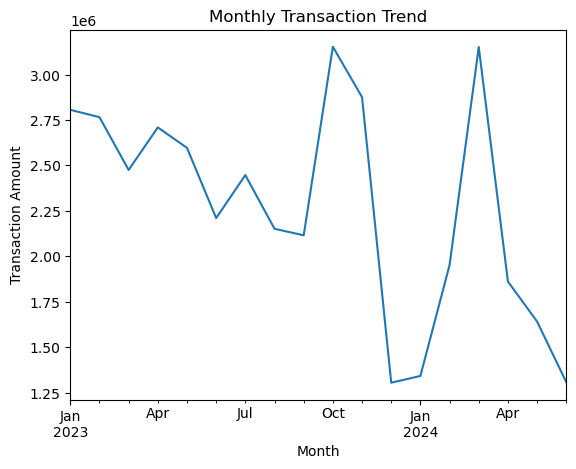

In [22]:
#Monthly Trend
monthly = df.groupby("Month")["TransactionAmount"].sum()
monthly.plot()
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Transaction Amount")
plt.show()

### Insight:
#### The line chart shows the trend of transactions over time. 
#### Increasing trends indicate growth in transaction activity, while fluctuations may indicate irregular behavior.

## Task 6: Hypothesis Testing 
#### ● Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.
#### ● Conduct hypothesis testing based on segmentation.

In [23]:
# Create threshold 
threshold = df["TransactionAmount"].median()

# Create groups
df["Volume_Group"] = df["TransactionAmount"].apply(lambda x: "High" if x > threshold else "Low")

df[["TransactionAmount", "Volume_Group"]].head()

,TransactionAmount,Volume_Group
0,33759.69057,Low
1,69319.19933,High
2,42831.48483,Low
3,70903.79697,High
4,21948.97355,Low


### Customers are divided into High and Low transaction volume groups based on median transaction amount.

In [24]:
# 6.2: Compare Average Balance
df.groupby("Volume_Group")["AccountBalance"].mean()

Volume_Group
High    74376.720314
Low     74679.289735
Name: AccountBalance, dtype: float64

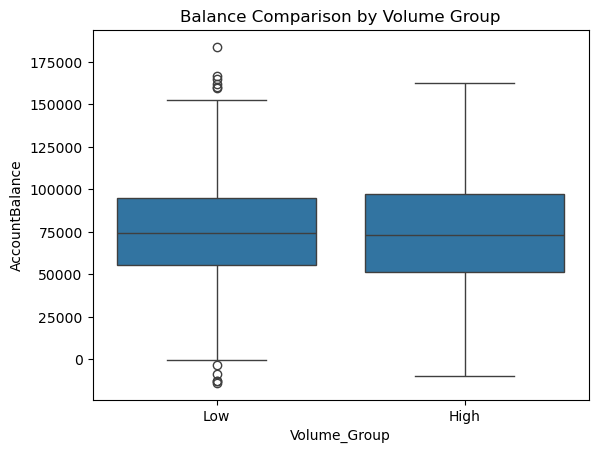

In [25]:
sns.boxplot(x="Volume_Group", y="AccountBalance", data=df)
plt.title("Balance Comparison by Volume Group")
plt.show()

### Insight:The average balance of high-volume and low-volume groups is compared to observe initial differences.

## Hypothesis Testing (T-Test)

In [26]:
from scipy.stats import ttest_ind

# Separate groups
high_group = df[df["Volume_Group"] == "High"]["AccountBalance"]
low_group = df[df["Volume_Group"] == "Low"]["AccountBalance"]

# Perform test
t_stat, p_value = ttest_ind(high_group, low_group)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.13114299015733347
P-value: 0.8956952476134932


In [27]:
# Decision
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


### : Hypothesis Result

#### - Null Hypothesis: No difference in average balance
#### - Alternative Hypothesis: High-volume accounts have higher balance

### Conclusion:If p-value < 0.05, we reject the null hypothesis, indicating a significant difference between the groups.